# Statistical Baseline Models for Solar Power Forecasting

This notebook establishes statistical baseline modelswith the SARIMA model for forecasting AC power output from solar inverters. This baseline will serve as reference points for evaluating more sophisticated Machine Learning and Deep Learning models.

## Evaluation Metrics:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Statistical modeling
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## Data Loading

In [2]:
# Load the dataset
DATA_PATH = '../../data/datasets/forecasting/statistical_models_dataset.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Inverters: {df['inverter_id'].unique()}")
print(f"\nData types:")
print(df.dtypes)
df.head(10)

Dataset shape: (1344175, 3)
Date range: 2026-02-01 19:41:00+00:00 to 2026-04-09 11:54:00+00:00
Inverters: <ArrowStringArray>
['A0', 'A1', 'A2', 'A3', 'B0', 'B1', 'B2', 'B3', 'C0', 'C1', 'C2', 'C3', 'C4',
 'C5']
Length: 14, dtype: str

Data types:
timestamp      datetime64[us, UTC]
ac_power_kw                float64
inverter_id                    str
dtype: object


,timestamp,ac_power_kw,inverter_id
0,2026-02-01 19:41:00+00:00,0.0,A0
1,2026-02-01 19:42:00+00:00,0.0,A0
2,2026-02-01 19:43:00+00:00,0.0,A0
3,2026-02-01 19:44:00+00:00,0.0,A0
4,2026-02-01 19:45:00+00:00,0.0,A0
5,2026-02-01 19:46:00+00:00,0.0,A0
6,2026-02-01 19:47:00+00:00,0.0,A0
7,2026-02-01 19:48:00+00:00,0.0,A0
8,2026-02-01 19:49:00+00:00,0.0,A0
9,2026-02-01 19:50:00+00:00,0.0,A0


In [3]:
# Basic statistics
print("Statistical Summary:")
print(df['ac_power_kw'].describe())

print(f"\nMissing values:")
print(df.isnull().sum())

print(f"\nRecords per inverter:")
print(df.groupby('inverter_id').size())

Statistical Summary:
count    1.344175e+06
mean     3.350172e+01
std      3.860660e+01
min      0.000000e+00
25%      3.000000e-03
50%      3.000000e-03
75%      7.985200e+01
max      9.015700e+01
Name: ac_power_kw, dtype: float64

Missing values:
timestamp      0
ac_power_kw    0
inverter_id    0
dtype: int64

Records per inverter:
inverter_id
A0    96010
A1    96012
A2    96014
A3    96012
B0    96014
B1    96013
B2    96013
B3    96013
C0    96013
C1    96013
C2    96012
C3    96011
C4    96012
C5    96013
dtype: int64


In [4]:
# Select a single inverter for modeling (A0 as reference)
# Statistical models work best with univariate time series
INVERTER_ID = 'A0'

df_inverter = df[df['inverter_id'] == INVERTER_ID].copy()
df_inverter = df_inverter.set_index('timestamp').sort_index()
df_inverter = df_inverter[['ac_power_kw']]

print(f"Selected inverter: {INVERTER_ID}")
print(f"Records: {len(df_inverter)}")
print(f"Date range: {df_inverter.index.min()} to {df_inverter.index.max()}")
df_inverter.head()

Selected inverter: A0
Records: 96010
Date range: 2026-02-01 19:41:00+00:00 to 2026-04-09 11:50:00+00:00


,ac_power_kw
timestamp,
2026-02-01 19:41:00+00:00,0.0
2026-02-01 19:42:00+00:00,0.0
2026-02-01 19:43:00+00:00,0.0
2026-02-01 19:44:00+00:00,0.0
2026-02-01 19:45:00+00:00,0.0


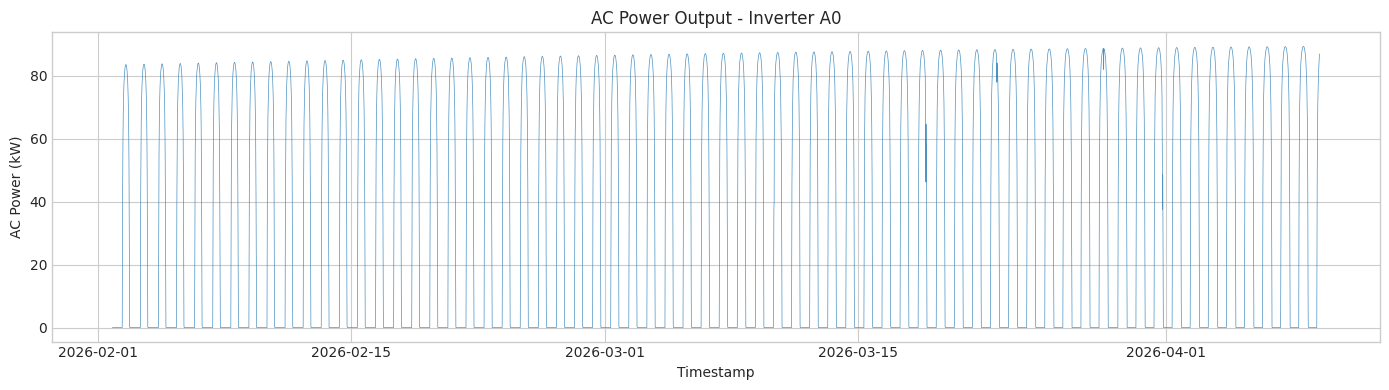

In [5]:
# Visualize the full time series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_inverter.index, df_inverter['ac_power_kw'], linewidth=0.5, alpha=0.8)
ax.set_xlabel('Timestamp')
ax.set_ylabel('AC Power (kW)')
ax.set_title(f'AC Power Output - Inverter {INVERTER_ID}')
plt.tight_layout()
plt.show()

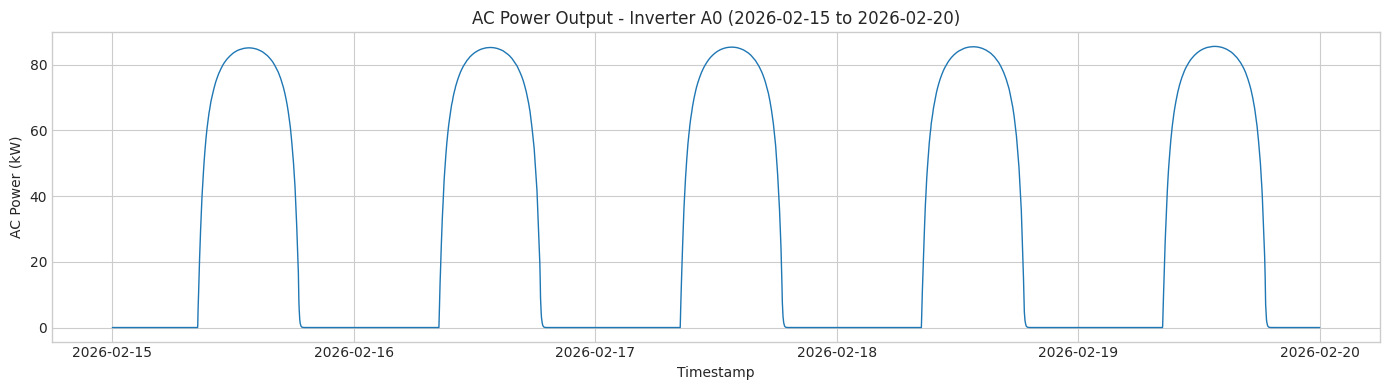

In [6]:
# Visualize a few days to see daily pattern
sample_start = '2026-02-15'
sample_end = '2026-02-20'

fig, ax = plt.subplots(figsize=(14, 4))
mask = (df_inverter.index >= sample_start) & (df_inverter.index < sample_end)
ax.plot(df_inverter.loc[mask].index, df_inverter.loc[mask]['ac_power_kw'], linewidth=1)
ax.set_xlabel('Timestamp')
ax.set_ylabel('AC Power (kW)')
ax.set_title(f'AC Power Output - Inverter {INVERTER_ID} ({sample_start} to {sample_end})')
plt.tight_layout()
plt.show()

## Data Preprocessing

For statistical models, we'll:
1. Resample to hourly data (minute-level is too granular for traditional statistical models)
2. Create train/test split (80/20)
3. Focus on day-ahead forecasting

In [7]:
# Resample to hourly data (mean aggregation)
df_hourly = df_inverter.resample('h').mean()

# Check for missing values after resampling
missing_hours = df_hourly['ac_power_kw'].isnull().sum()
print(f"Missing hours after resampling: {missing_hours}")

# Forward fill any gaps (if any)
df_hourly = df_hourly.ffill()

print(f"Hourly data shape: {df_hourly.shape}")
print(f"Date range: {df_hourly.index.min()} to {df_hourly.index.max()}")
df_hourly.head(24)

Missing hours after resampling: 0
Hourly data shape: (1601, 1)
Date range: 2026-02-01 19:00:00+00:00 to 2026-04-09 11:00:00+00:00


,ac_power_kw
timestamp,
2026-02-01 19:00:00+00:00,0.000000
2026-02-01 20:00:00+00:00,0.000000
2026-02-01 21:00:00+00:00,0.000000
2026-02-01 22:00:00+00:00,0.000000
2026-02-01 23:00:00+00:00,0.000000
2026-02-02 00:00:00+00:00,0.000000
2026-02-02 01:00:00+00:00,0.000000
2026-02-02 02:00:00+00:00,0.000000
2026-02-02 03:00:00+00:00,0.000000


Training set: 1280 hours (2026-02-01 19:00:00+00:00 to 2026-03-27 02:00:00+00:00)
Test set: 321 hours (2026-03-27 03:00:00+00:00 to 2026-04-09 11:00:00+00:00)


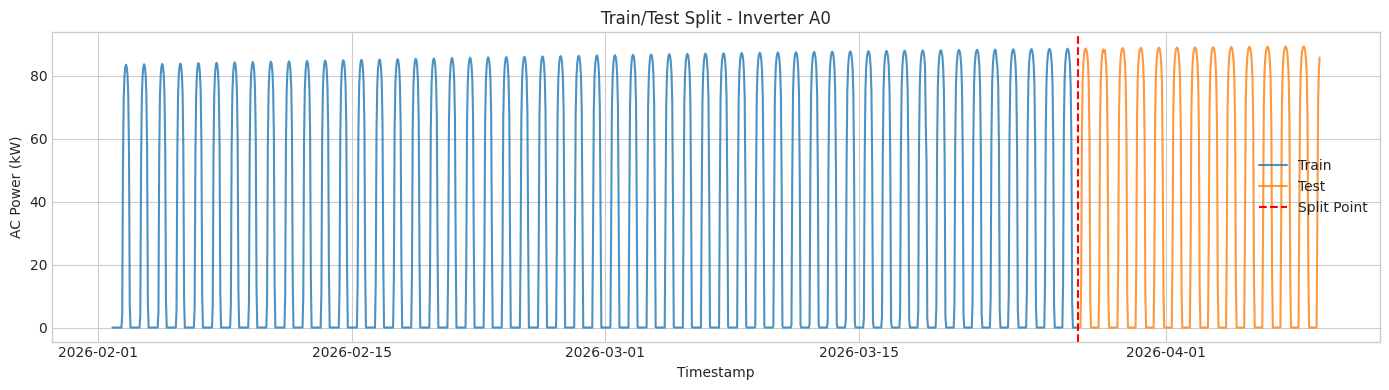

In [8]:
# Train/Test split (80/20)
train_size = int(len(df_hourly) * 0.8)
train = df_hourly.iloc[:train_size]
test = df_hourly.iloc[train_size:]

print(f"Training set: {len(train)} hours ({train.index.min()} to {train.index.max()})")
print(f"Test set: {len(test)} hours ({test.index.min()} to {test.index.max()})")

# Visualize split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['ac_power_kw'], label='Train', alpha=0.8)
ax.plot(test.index, test['ac_power_kw'], label='Test', alpha=0.8)
ax.axvline(x=test.index[0], color='red', linestyle='--', label='Split Point')
ax.set_xlabel('Timestamp')
ax.set_ylabel('AC Power (kW)')
ax.set_title(f'Train/Test Split - Inverter {INVERTER_ID}')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Helper functions for evaluation
def calculate_metrics(y_true, y_pred):
    """Calculate MAE, RMSE, and MAPE"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # MAPE - avoid division by zero
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

def plot_forecast(y_true, y_pred, title, hours_to_show=168):
    """Plot actual vs predicted values"""
    fig, axes = plt.subplots(2, 1, figsize=(14, 6))
    
    # Full test period
    axes[0].plot(y_true.index, y_true.values, label='Actual', alpha=0.8)
    axes[0].plot(y_true.index, y_pred, label='Forecast', alpha=0.8)
    axes[0].set_title(f'{title} - Full Test Period')
    axes[0].set_ylabel('AC Power (kW)')
    axes[0].legend()
    
    # First N hours detail
    axes[1].plot(y_true.index[:hours_to_show], y_true.values[:hours_to_show], label='Actual', alpha=0.8)
    axes[1].plot(y_true.index[:hours_to_show], y_pred[:hours_to_show], label='Forecast', alpha=0.8)
    axes[1].set_title(f'{title} - First {hours_to_show} Hours')
    axes[1].set_xlabel('Timestamp')
    axes[1].set_ylabel('AC Power (kW)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# Store results for comparison
results = {}

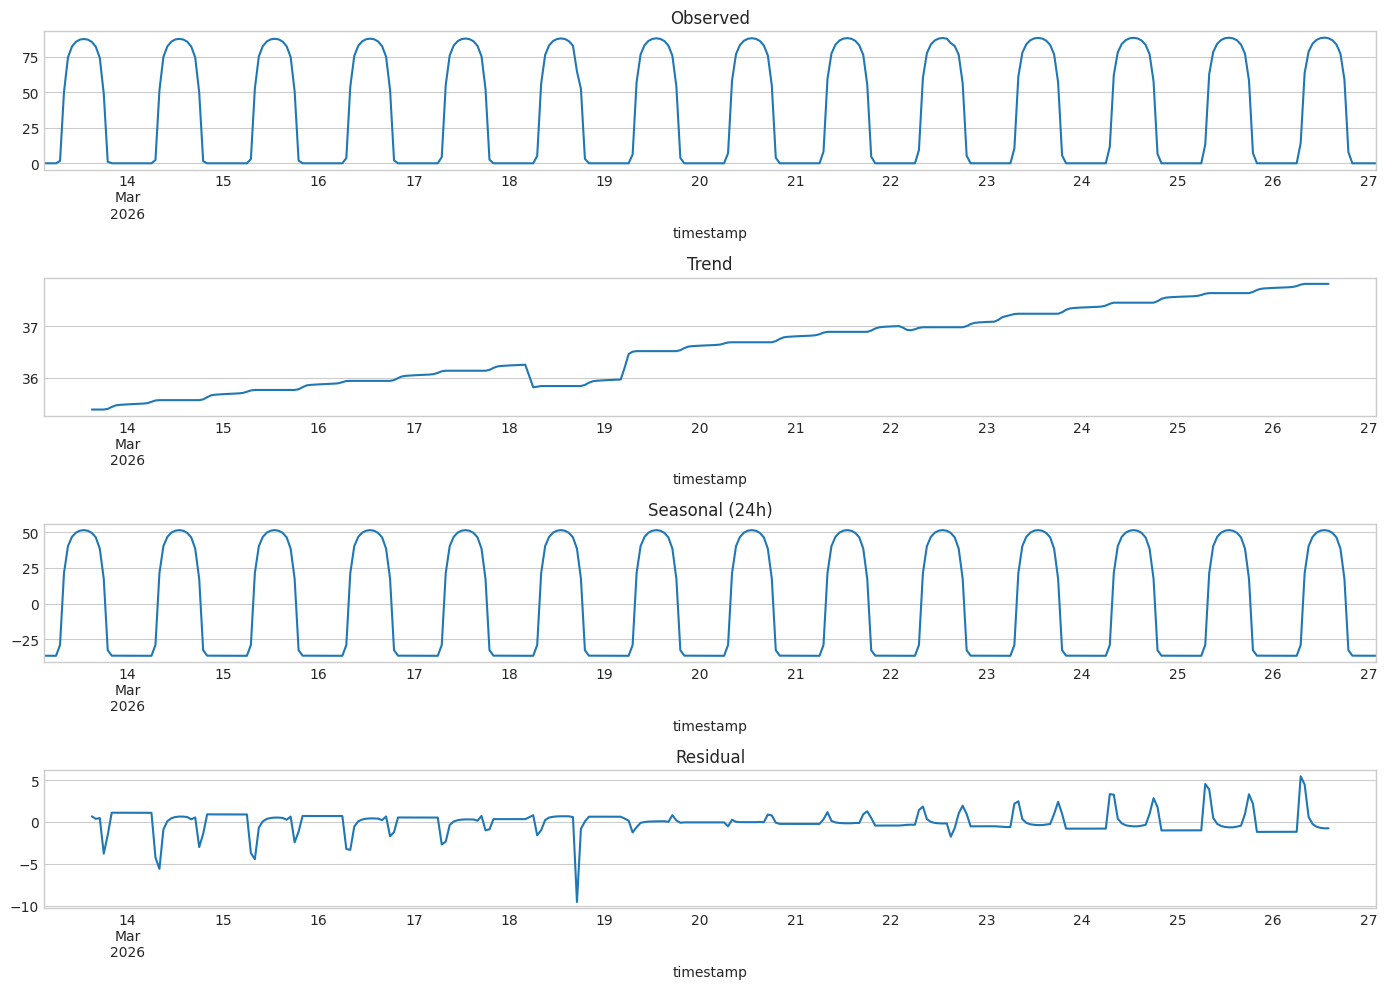

In [10]:
# Time series decomposition to understand components
# Use only a subset for visualization (too much data makes it hard to read)
decomposition = seasonal_decompose(train['ac_power_kw'][-24*14:], model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal (24h)')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

## SARIMA Model

SARIMA (Seasonal ARIMA) extends ARIMA by including seasonal components:
- **Seasonal (P, D, Q, m)**: Seasonal AR, I, MA counterparts with seasonal period m

This allows SARIMA to capture the strong daily seasonality (24-hour cycle) in solar power generation that ARIMA cannot model.

In [11]:
# SARIMA model
# Using a subset of training data for faster computation
# Parameters: (p, d, q) x (P, D, Q, m)
# p, d, q: Non-seasonal AR, I, MA orders
# P, D, Q: Seasonal AR, I, MA orders
# m: Seasonal period (24 for hourly data with daily seasonality)

# Use last 14 days of training data to speed up fitting
train_subset = train['ac_power_kw'][-24*14:]

print("Fitting SARIMA model (this may take a few minutes)...")

# SARIMA(1,1,1)(1,1,1,24) - a common starting point for daily seasonal data
sarima_model = SARIMAX(
    train_subset,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("\nSARIMA Model Summary:")
print(sarima_model.summary().tables[0])

Fitting SARIMA model (this may take a few minutes)...

SARIMA Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                        ac_power_kw   No. Observations:                  336
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood                -376.732
Date:                            Sun, 15 Feb 2026   AIC                            763.464
Time:                                    20:43:06   BIC                            781.727
Sample:                                03-13-2026   HQIC                           770.785
                                     - 03-27-2026                                         
Covariance Type:                              opg                                         


In [12]:
# Generate forecasts for test period
# Note: For very long horizons, SARIMA may not perform well
# We'll forecast a shorter horizon and use rolling forecasts for extended periods

forecast_horizon = min(len(test), 24*7)  # Limit to 7 days for SARIMA

sarima_forecast = sarima_model.forecast(forecast_horizon)
sarima_pred = np.clip(sarima_forecast.values, 0, None)  # Clip to non-negative

# Calculate metrics for the forecast horizon
results['SARIMA (1,1,1)(1,1,1,24)'] = calculate_metrics(
    test['ac_power_kw'].iloc[:forecast_horizon].values, 
    sarima_pred
)
print(f"SARIMA(1,1,1)(1,1,1,24) - Forecast horizon: {forecast_horizon} hours")
print(f"  MAE:  {results['SARIMA (1,1,1)(1,1,1,24)']['MAE']:.4f} kW")
print(f"  RMSE: {results['SARIMA (1,1,1)(1,1,1,24)']['RMSE']:.4f} kW")
print(f"  MAPE: {results['SARIMA (1,1,1)(1,1,1,24)']['MAPE']:.2f}%")

SARIMA(1,1,1)(1,1,1,24) - Forecast horizon: 168 hours
  MAE:  5.5029 kW
  RMSE: 12.6753 kW
  MAPE: 26286.59%


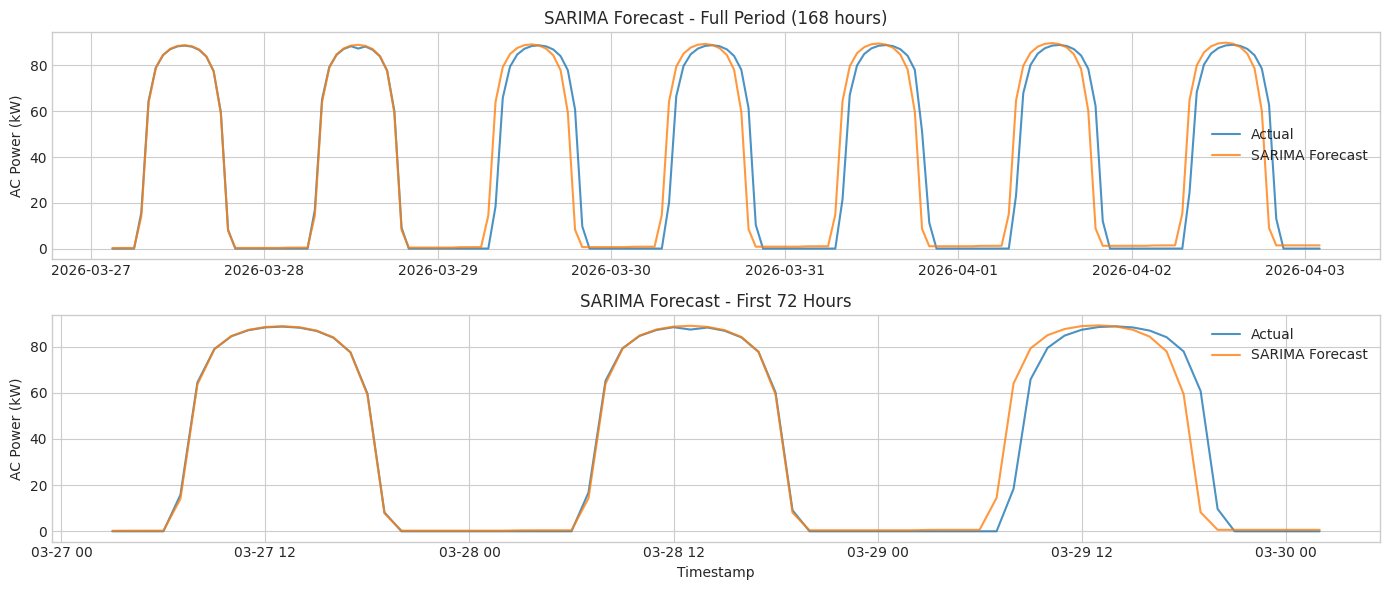

In [13]:
# Visualize SARIMA forecast
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Full forecast period
test_subset = test['ac_power_kw'].iloc[:forecast_horizon]
axes[0].plot(test_subset.index, test_subset.values, label='Actual', alpha=0.8)
axes[0].plot(test_subset.index, sarima_pred, label='SARIMA Forecast', alpha=0.8)
axes[0].set_title(f'SARIMA Forecast - Full Period ({forecast_horizon} hours)')
axes[0].set_ylabel('AC Power (kW)')
axes[0].legend()

# First 72 hours detail
hours_detail = min(72, forecast_horizon)
axes[1].plot(test_subset.index[:hours_detail], test_subset.values[:hours_detail], label='Actual', alpha=0.8)
axes[1].plot(test_subset.index[:hours_detail], sarima_pred[:hours_detail], label='SARIMA Forecast', alpha=0.8)
axes[1].set_title(f'SARIMA Forecast - First {hours_detail} Hours')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('AC Power (kW)')
axes[1].legend()

plt.tight_layout()
plt.show()